# SOR Speedup 


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from numba import njit, prange
import cupy as cp

### SOR python implementation

In [2]:
# SOR solver in pure Python implementation
def sor_py(N, eps, omega, mask, max_iter=200_000):
    c = np.zeros((N+1, N+1), dtype=np.float64)
    for j in range(N+1):
        c[:, j]=j/N
    # SOR iteration
    for k in range(max_iter):
        mx=0
        for i in range(N+1):
            for j in range(N+1):
                # Skipping masked points and boundary conditions
                if mask[i, j]==1:
                    c[i, j]=0
                    continue
                # Boundary conditions
                if j==0:
                    c[i, j]=0
                    continue
                if j==N:
                    c[i, j]=1
                    continue
                # SOR update
                ip=(i+1)%(N+1)
                im=(i-1)%(N+1)
                old=c[i, j]
                new=(omega/4)*(c[ip, j] + c[im, j] + c[i, j+1] + c[i, j-1]) + (1 - omega)*old
                c[i, j]=new
                mx = max(mx, abs(new-old))
        # Enforcing boundary conditions and mask after the update
        c[:, 0]=0
        c[:, N]=1
        for ii in range(N+1):
            for jj in range(N+1):
                if mask[ii, jj]==1:
                    c[ii, jj]=0
        if mx<eps:
            return c, k + 1
    return c, max_iter

### SOR Numba JIT compiled implementation

In [3]:
# SOR solver with Numba JIT compilation implementation
@njit
def sor_jit(N, eps, omega, mask, max_iter=200_000):
    c = np.zeros((N+1, N+1), dtype=np.float64)
    # Initializing the solution with boundary conditions
    for j in range(N+1):
        c[:, j]=j/N
    # SOR iteration
    for k in range(max_iter):
        mx=0
        for i in range(N+1):
            for j in range(N+1):
                # Skipping masked points and boundary conditions
                if mask[i, j]==1:
                    c[i, j]=0
                    continue
                if j==0:
                    c[i, j]=0
                    continue
                if j==N:
                    c[i, j]=1
                    continue
                # SOR update
                ip=(i+1)%(N+1)
                im=(i-1)%(N+1)
                old=c[i, j]
                new=(omega/4)*(c[ip,j] + c[im, j] + c[i, j+1] + c[i, j-1]) + (1-omega)*old
                c[i, j]=new
                d=abs(new-old)
                if d>mx:
                    mx=d
        # Enforcing boundary conditions and mask after the update
        c[:, 0]=0
        c[:, N]=1
        for ii in range(N+1):
            for jj in range(N+1):
                if mask[ii, jj]==1:
                    c[ii, jj]=0
        if mx<eps:
            break
    return c, k+1

### Red-Black Parallel SOR (`sor_rb`)
Standard SOR is sequential, each update uses already updated neighbours. Red-black ordering splits the grid into two checkerboard colors. All red cells only depend on black cells and vice versa, so each color can be updated fully in parallel using `prange`.


In [4]:
# SOR Solver with Red-Black ordering and Numba JIT compilation
# This implementation updates red points and black points in 
# separate loops to allow for better parallelization.
# The red points are those where (i+j) is even, 
# and the black points are those where (i+j) is odd
@njit(parallel=True)
def sor_rb(N, eps, omega, mask, max_iter=200_000):
    c = np.zeros((N+1, N+1), dtype=np.float64)
    # Initializing the solution with boundary conditions
    for j in range(N+1):
        c[:,j] = j/N
    # SOR iteration with Red-Black ordering
    for k in range(max_iter):
        mx=0
        # Red-Black ordering, first update red points, then black points
        for col in range(2):
            for i in prange(N+1):
                for j in range(N+1):
                    # Skipping masked points and boundary conditions
                    if (i+j)%2!=col:
                        continue
                    if mask[i,j] == 1:
                        c[i,j] = 0
                        continue
                    if j==0:
                        c[i,j] = 0
                        continue
                    if j == N:
                        c[i, j] = 1
                        continue
                    # SOR update
                    ip=(i+1)%(N+1)
                    im=(i-1)%(N+1)
                    old=c[i,j]
                    new=(omega/4)*(c[ip,j]+c[im,j]+c[i,j+1]+c[i,j-1])+(1-omega)*old
                    c[i,j]=new
                    d=abs(new - old)
                    if d>mx:
                        mx=d
        # Enforcing boundary conditions and mask after the update
        c[:, 0]=0
        c[:, N]=1
        for ii in prange(N+1):
            for jj in range(N+1):
                if mask[ii,jj]==1:
                    c[ii, jj]=0
        if mx < eps:
            break
    return c, k + 1

### GPU SOR (`sor_gpu`)
Same red-black idea but on GPU using CuPy. Neighbour sums are computed with `cp.roll` and the SOR update is applied to all cells of one color in a single vectorized operation. Trades loop overhead for memory allocation overhead but should benefit large grids.


In [5]:
# SOR Solver with Red-Black ordering and GPU acceleration using CuPy
# This implementation updates red points and black points in
# separate loops to allow for better parallelization.

def sor_gpu(N, eps, omega, mask_np, max_iter=200_000):
    # Initializing the solution with boundary conditions
    c = cp.zeros((N+1, N+1), dtype=cp.float64)
    for j in range(N+1):
        c[:,j]=j/N
    # Converting the mask to a CuPy array
    mask=cp.asarray(mask_np)
    w4=omega/4
    w1=1-omega
    # Preparing boundary condition arrays and sink mask
    sink = mask==1
    bc_bot = cp.zeros(N+1, dtype=cp.float64)
    bc_top = cp.ones(N+1, dtype=cp.float64)
    # Creating index arrays for red-black ordering
    ii, jj = cp.meshgrid(cp.arange(N+1), cp.arange(N+1), indexing="ij")
    inter = (jj>0) & (jj<N) & (~sink)
    red = inter & ((ii + jj)%2==0)
    blk = inter & ((ii + jj)%2==1)
    # SOR iteration with Red-Black ordering on GPU
    for k in range(max_iter):
        c_old = c.copy()
        for sel in [red, blk]:
            nb = (cp.roll(c, -1, 0) + cp.roll(c, 1, 0)+cp.roll(c, -1, 1) + cp.roll(c, 1, 1))
            c_new = w4*nb + w1*c
            c[sel] = c_new[sel]
        # Enforcing boundary conditions and mask after the update
        c[:, 0] = bc_bot
        c[:, N] = bc_top
        c[sink] = 0

        mx = float(cp.max(cp.abs(c - c_old)))
        if mx<eps:
            break

    cp.cuda.Stream.null.synchronize()
    return cp.asnumpy(c), k + 1

### Warmup
First call to `@njit` functions includes compilation time. We run each once on a small grid so the benchmark only measures execution time.

In [6]:
# Warmup run to compile the JIT functions and initialize the GPU
eps = 1e-5
omega = 1.8

dm = np.zeros((51, 51), dtype=np.int64)
dm[25, 1] = 1


sor_jit(50, eps, omega, dm)
sor_rb(50, eps, omega, dm)
sor_gpu(50, eps, omega, dm)



(array([[0.        , 0.01998432, 0.03996961, ..., 0.96      , 0.98      ,
         1.        ],
        [0.        , 0.01998384, 0.03996739, ..., 0.96      , 0.98      ,
         1.        ],
        [0.        , 0.01998224, 0.03996549, ..., 0.96      , 0.98      ,
         1.        ],
        ...,
        [0.        , 0.01998224, 0.03996549, ..., 0.96      , 0.98      ,
         1.        ],
        [0.        , 0.01998384, 0.03996739, ..., 0.96      , 0.98      ,
         1.        ],
        [0.        , 0.01998432, 0.03996961, ..., 0.96      , 0.98      ,
         1.        ]]),
 34)

In [9]:
# experiment loop to benchmark the different implementations on a range 
# of grid sizes. For each size, we run each implementation 3 times and take
# the minimum time to account for variability in execution time.

sizes = [50, 100, 200, 300, 400, 500, 700, 1000]
t_py, t_jit, t_rb, t_gpu = [], [], [], []

hdr = f"{'N':>6}  {'Py':>10}  {'GPU':>10} {'JIT':>10}  {'RB':>10}"
print(hdr)
print("-" * len(hdr))

for Nc in sizes:
    # Initializing the mask for the current grid size
    m = np.zeros((Nc+1, Nc+1), dtype=np.int64)
    m[Nc//2, 1]=1
    
    # Benchmarking the pure Python implementation
    res=[]
    for _ in range(3):
        t0 = time.perf_counter()
        sor_py(Nc, eps, omega, m)
        res.append(time.perf_counter() - t0)
    tp = min(res)
    # Benchmarking the JIT-compiled implementation
    res=[]
    for _ in range(3):
        t0 = time.perf_counter()
        sor_jit(Nc, eps, omega, m)
        res.append(time.perf_counter() - t0)
    tj = min(res)
    # Benchmarking the Red-Black ordered implementation
    res=[]
    for _ in range(3):
        t0 = time.perf_counter()
        sor_rb(Nc, eps, omega, m)
        res.append(time.perf_counter() - t0)
    tr = min(res)
    # Benchmarking the GPU accelerated implementation
    res=[]
    for _ in range(3):
        t0 = time.perf_counter()
        sor_gpu(Nc, eps, omega, m)
        res.append(time.perf_counter() - t0)
    tg = min(res)

    t_py.append(tp*1000)
    t_jit.append(tj*1000)
    t_rb.append(tr*1000)
    t_gpu.append(tg*1000)
    print(f"{Nc:>6}  {tp*1000:>9.2f}ms  {tg*1000:>9.2f}ms  {tj*1000:>9.2f}ms  {tr*1000:>9.2f}ms")

     N          Py         GPU        JIT          RB
-----------------------------------------------------
    50     145.26ms      56.81ms       0.80ms       0.40ms
   100     473.25ms      43.89ms       2.63ms       0.78ms
   200    1710.95ms      53.03ms      16.09ms       1.79ms
   300    3614.39ms      52.10ms      32.60ms       3.23ms
   400    6173.26ms      38.60ms      31.20ms       3.73ms
   500    8824.08ms      52.23ms      55.23ms       9.93ms
   700   17491.07ms      45.11ms      86.95ms       9.67ms
  1000   31816.80ms      68.18ms     154.16ms      18.17ms


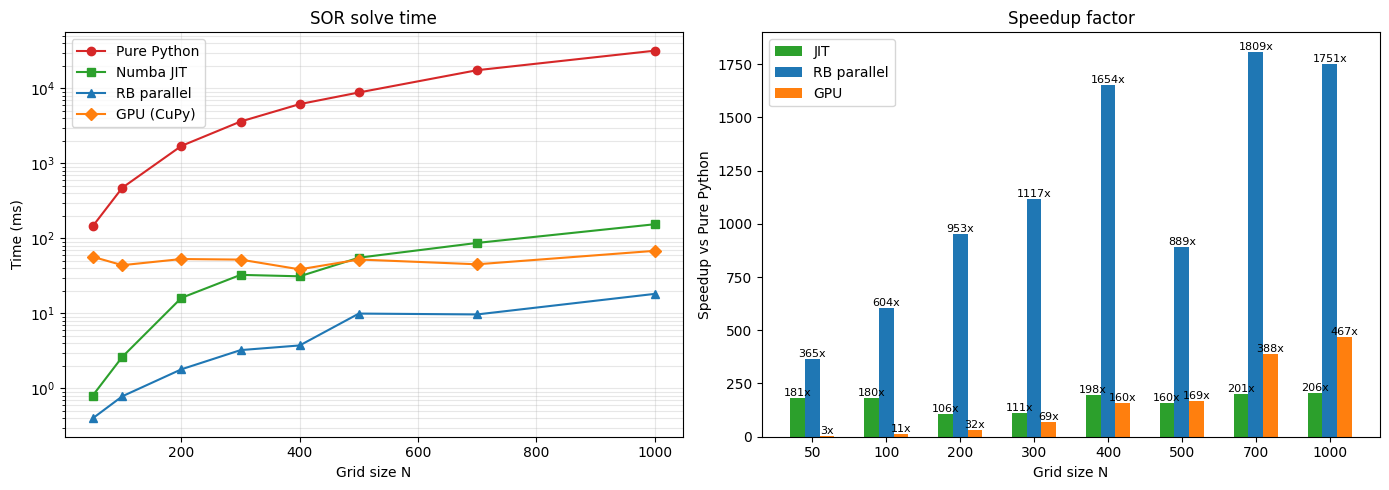

In [10]:
# plots to visualize the results

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Plotting the execution times on a logarithmic scale
ax1.plot(sizes, t_py, "o-", color="#d62728", label="Pure Python")
ax1.plot(sizes, t_jit, "s-", color="#2ca02c", label="Numba JIT")
ax1.plot(sizes, t_rb, "^-", color="#1f77b4", label="RB parallel")
ax1.plot(sizes, t_gpu, "D-", color="#ff7f0e", label="GPU (CuPy)")
ax1.set_yscale("log")
ax1.set_xlabel("Grid size N")
ax1.set_ylabel("Time (ms)")
ax1.set_title("SOR solve time")
ax1.legend()
ax1.grid(alpha=0.3, which="both")

x = np.arange(len(sizes))
w = 0.2
sp_jit = [p / j for p, j in zip(t_py, t_jit)]
sp_rb = [p / r for p, r in zip(t_py, t_rb)]
sp_gpu = [p / g for p, g in zip(t_py, t_gpu)]

# Plotting the speedup factors as a bar chart
ax2.bar(x - w, sp_jit, w, label="JIT", color="#2ca02c")
ax2.bar(x, sp_rb, w, label="RB parallel", color="#1f77b4")
ax2.bar(x + w, sp_gpu, w, label="GPU", color="#ff7f0e")
ax2.set_xticks(x)
ax2.set_xticklabels([str(s) for s in sizes])
ax2.set_xlabel("Grid size N")
ax2.set_ylabel("Speedup vs Pure Python")
ax2.set_title("Speedup factor")
ax2.legend()
for i, (sj, sr, sg) in enumerate(zip(sp_jit, sp_rb, sp_gpu)):
    ax2.annotate(f"{sj:.0f}x", xy=(i - w, sj), ha="center", va="bottom", fontsize=8)
    ax2.annotate(f"{sr:.0f}x", xy=(i, sr), ha="center", va="bottom", fontsize=8)
    ax2.annotate(f"{sg:.0f}x", xy=(i + w, sg), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
# plt.savefig("sor_benchmark_all.png", dpi=300)
plt.show()

### Discussion

The left plot shows time on a log scale across grid sizes N=50 to N=1000. Pure Python scales steeply, while JIT, RB parallel, and GPU all remain orders of magnitude faster. The right plot shows speedup relative to Pure Python.

- **JIT** provides a consistent ~160–200x speedup by compiling the same Python loops to machine code.
- **RB parallel** scales best, reaching ~1800x at N=700 by distributing the red-black sweeps across CPU cores.
- **GPU** shows nearvconstant time (~40–80ms) regardless of grid size due to memory allocation overhead from `cp.roll`, but its speedup grows steadily, reaching ~467x at N=1000. For very large grids the GPU would overtake RB parallel as compute starts to dominate the overhead.